In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('Telco_churn.csv')


In [6]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
#eplacing blanks with 0 as tenure is 0  and no total charges are recorded

df['TotalCharges']=df['TotalCharges'].replace(" ","0")
df['TotalCharges']=df['TotalCharges'].astype("float")


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [10]:
df.isnull().sum().sum()

0

In [11]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [12]:
df.duplicated("customerID").sum()

0

In [13]:
#converted 0 and 1 values of SeniorCitizen to yes/no  to make it easier to undersatand.

def conv(value):
    if value ==1:
        return"yes"
    else:
        return"no"

df["SeniorCitizen"] = df["SeniorCitizen"].apply(conv)

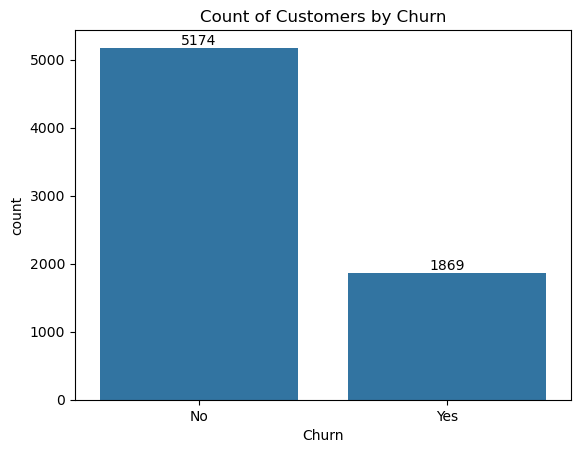

In [14]:
ax = sns.countplot(x = "Churn", data = df)

ax.bar_label(ax.containers[0])
plt.title("Count of Customers by Churn")
plt.show()

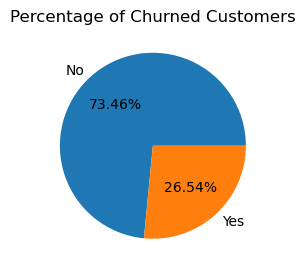

In [15]:
gb= df.groupby("Churn").agg({'Churn':'count'})
plt.figure(figsize=(3,4))
plt.pie(gb["Churn"], labels = gb.index ,  autopct = "%1.2f%%")
plt.title("Percentage of Churned Customers")
plt.show()

#From the given pie chart we can conclude  that 26.54% of our customers have churned out.<br>
#Lets Explore the reason behind it

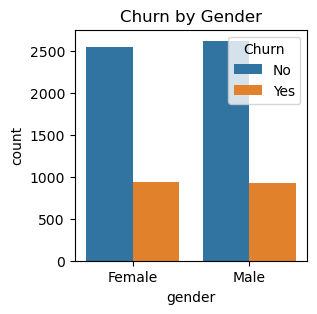

In [17]:

plt.figure(figsize =(3,3))
sns.countplot(x= 'gender', data = df, hue = "Churn")

plt.title("Churn by Gender")
plt.show()


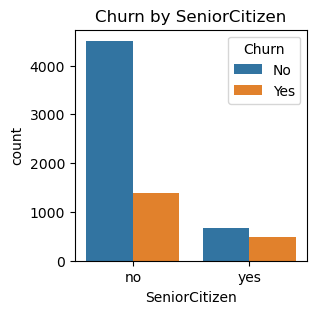

In [18]:
plt.figure(figsize =(3,3))
sns.countplot(x= 'SeniorCitizen', data = df, hue = "Churn")

plt.title("Churn by SeniorCitizen")
plt.show()


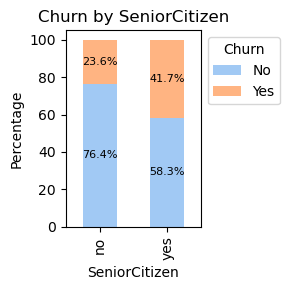

In [19]:
# Calculate percentages for the labels
data = df.groupby(['SeniorCitizen', 'Churn']).size().reset_index(name='count')
data['percent'] = data['count'] / data.groupby('SeniorCitizen')['count'].transform('sum') * 100

# Pivot for stacked bar chart
pivot_data = data.pivot(index='SeniorCitizen', columns='Churn', values='percent')

# Plot
pivot_data.plot(kind='bar', stacked=True, figsize=(3, 3), color=sns.color_palette('pastel'))

# Add percentages as text labels
for i, bar in enumerate(plt.gca().patches):
    height = bar.get_height()
    plt.gca().text(bar.get_x() + bar.get_width() / 2, bar.get_y() + height / 2,
                   f'{height:.1f}%', ha='center', va='center', fontsize=8)

# Titles and labels
plt.title("Churn by SeniorCitizen")
plt.xlabel("SeniorCitizen")
plt.ylabel("Percentage")
plt.legend(title="Churn", bbox_to_anchor=(1,1))
plt.tight_layout()

plt.show()

#comparetively a larger percentage of Seniorcitizen's have Churned..

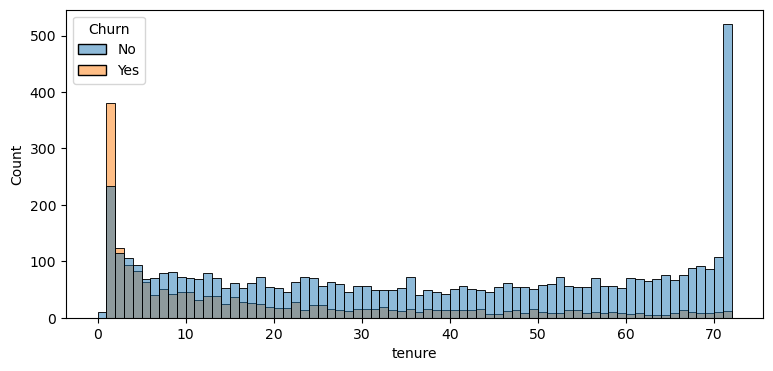

In [21]:
plt.figure(figsize =(9,4), )
sns.histplot(x ="tenure" , data = df , bins = 72, hue = 'Churn')
plt.show()

#people who have used our services for a long time have stayed , the rest who not used for long time have Churned 

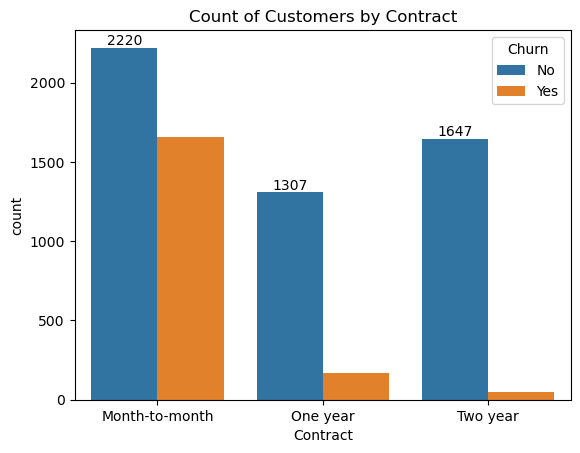

In [23]:
ax = sns.countplot(x = "Contract", data = df , hue = 'Churn')

ax.bar_label(ax.containers[0])
plt.title("Count of Customers by Contract")
plt.show()


#people who have month to month contract have more churned than those of 1 or 2 year contracts 

In [26]:
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

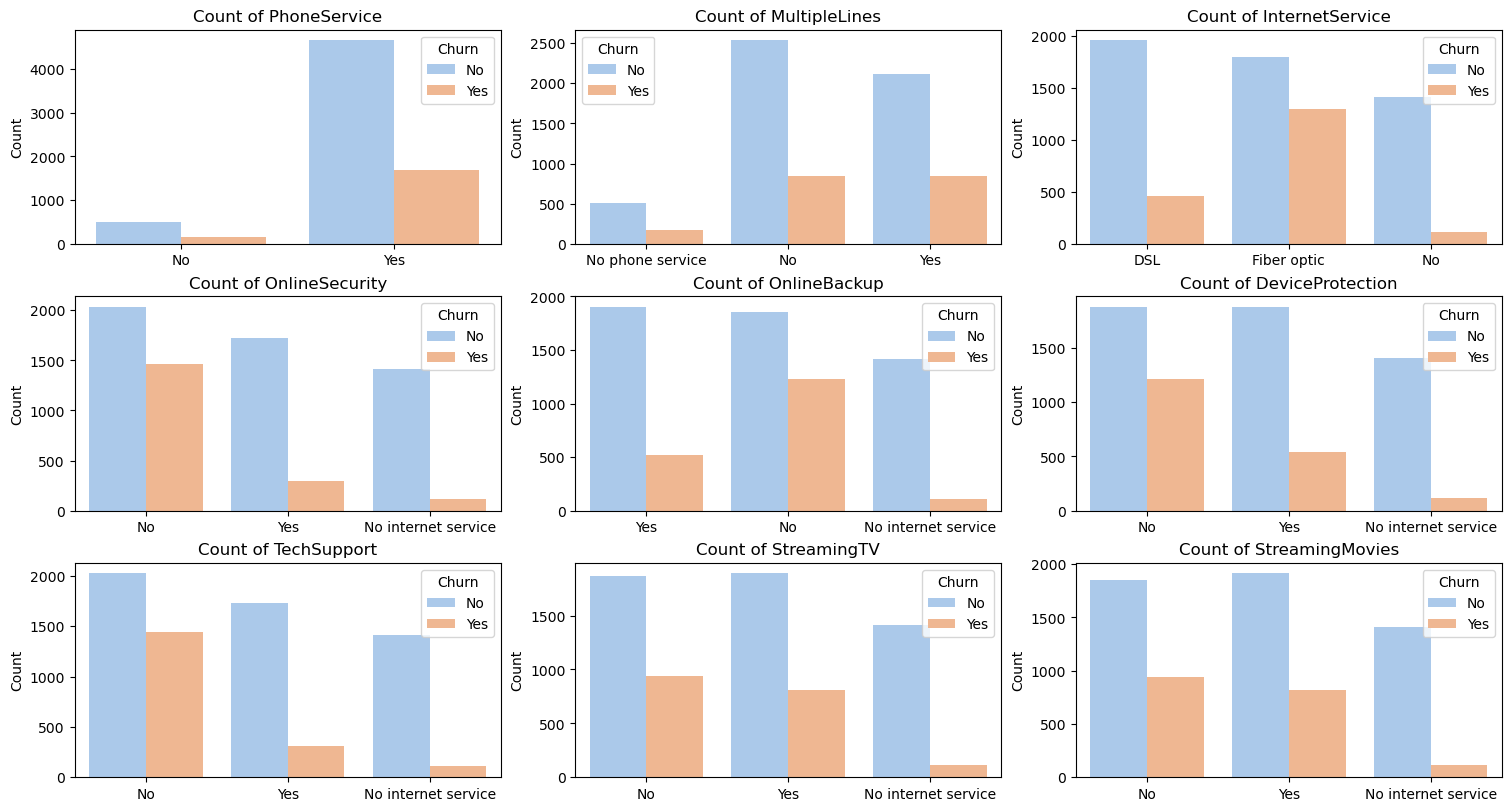

In [29]:
# List of columns
columns = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# Set up the subplot grid
n_cols = 3  # Number of columns in the grid
n_rows = -(-len(columns) // n_cols)  # Calculate the number of rows needed (ceiling division)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 8), constrained_layout=True)

# Flatten the axes array for easier iteration
axes = axes.flatten()

# Create countplots for each column
for i, col in enumerate(columns):
    sns.countplot(x=col, data=df, ax=axes[i],hue = df['Churn'], palette='pastel')
    axes[i].set_title(f"Count of {col}")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

# Show the plots
plt.show()

#The majority of the customers who do not churn tend to have services linke phoneservice, InternetService  and onlineSecurity enabled. <br>
For services like OnlineBackup , Techsupport , and streamingTV, churn rates are noticible higher when these services are not used or available.

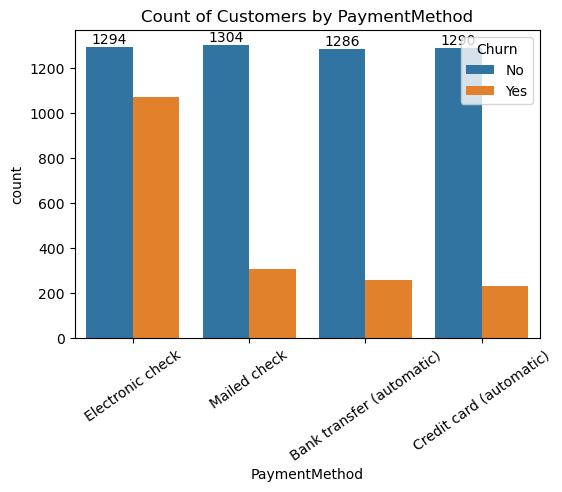

In [52]:
plt.figure(figsize = (6,4))
ax = sns.countplot(x = "PaymentMethod", data = df , hue = 'Churn')

ax.bar_label(ax.containers[0])
plt.title("Count of Customers by PaymentMethod") 
plt.xticks(rotation =35)
plt.show()


#customers likely to churn when they are using electronic check as a payment method